## Dataset Description

The Leuven.cool dataset contains meteorological measurements collected
from a network of urban sensors.

Below are the key variables used in this project:

| Column Name | Description | Unit | Usage |
|------------|------------|------|-------|
| ID | Unique identifier of each sensor station | - | Used to group measurements and merge with station metadata |
| TEMPF | Temperature measured at the sensor | Fahrenheit (°F) | Converted to Celsius and used as target variable |
| DATEUTC | Timestamp of measurement in UTC | datetime | Used to filter data for a specific date |
| LATITUDE | Geographic latitude of the station | degrees | Used for spatial mapping |
| LONGITUDE | Geographic longitude of the station | degrees | Used for spatial mapping |
| temp_c | Temperature converted to Celsius | Celsius (°C) | Final target variable for the model |

### Notes

- Temperature is originally recorded in Fahrenheit and converted to Celsius
  for easier interpretation.
- The dataset contains high-frequency measurements, which are aggregated
  to obtain a single value per sensor.
- Geographic coordinates are obtained from a separate metadata file
  and merged using the station ID.

In [122]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pyproj import Transformer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

### Loading Satellite Data (Sentinel-2)

In this step, we load satellite imagery from the Copernicus Sentinel-2 dataset.

We specifically use:
- **Band 4 (Red)**  
- **Band 8 (Near Infrared)**  

These bands are essential for computing vegetation indices such as NDVI, which will later help us analyze the relationship between vegetation and temperature.

In [123]:
BASE_DIR = Path().resolve().parent

B04_path = BASE_DIR / "data/raw/sentinel2/B04.jp2"
B08_path = BASE_DIR / "data/raw/sentinel2/B08.jp2"

with rasterio.open(B04_path) as src:
    red = src.read(1)

with rasterio.open(B08_path) as src:
    nir = src.read(1)

print("Shape:", red.shape)

Shape: (10980, 10980)


## NDVI Computation

To analyze vegetation coverage, we compute the Normalized Difference Vegetation Index (NDVI).

NDVI is calculated using the Red (B04) and Near-Infrared (B08) bands:

- Vegetation reflects more NIR and absorbs red light
- This makes NDVI a good indicator of plant health

Expected values:
- Close to +1 → dense vegetation
- Around 0 → bare soil
- Negative → water or urban surfaces

In [124]:
red = red.astype(np.float32)
nir = nir.astype(np.float32)

ndvi = (nir - red) / (nir + red + 1e-6)

## Loading Leuven.cool Dataset

We load temperature measurements from Leuven.cool, which provides
ground-based sensor data across the city.

This data will serve as ground truth for training our model.

In [125]:
df = pd.read_csv("../data/raw/leuven/RAWDATA2025Q3.csv", nrows=100000)
stations = pd.read_csv("../data/raw/leuven/stations.csv")

print(df.columns)
print(stations.columns)

Index(['OBSID', 'ID', 'TEMPF', 'HUMIDITY', 'DEWPTF', 'WINDCHILLF', 'WINDDIR',
       'WINDSPEEDMPH', 'WINDGUSTMPH', 'RAININ', 'DAILYRAININ',
       'SOLARRADIATION', 'UV', 'BAROMIN', 'DATEUTC', 'DATEUTC_STAT'],
      dtype='str')
Index(['ID', 'WOWID', 'LATITUDE', 'LONGITUDE', 'ALTITUDE'], dtype='str')


## Filtering Temperature Data

To align the ground sensor measurements with the satellite image,
we filter the dataset for the closest available date.

Although the satellite image was acquired on 2025-07-02, the sensor
data is only available for 2025-07-01. Therefore, we use this date
as an approximation.

This is acceptable because temperature patterns change gradually,
and the selected date is temporally close to the satellite observation.

In [126]:
# Convert temperature to Celsius
df['temp_c'] = (df['TEMPF'] - 32) * 5/9

# Convert timestamp
df['DATEUTC'] = pd.to_datetime(df['DATEUTC'])

# Filter for closest available date
df_day = df[
    (df['DATEUTC'] >= '2025-07-01') &
    (df['DATEUTC'] < '2025-07-02')
]

print(df_day.head())

        OBSID         ID  TEMPF  HUMIDITY  DEWPTF  WINDCHILLF  WINDDIR  \
0  1057644192  GARMON062   74.8        69    64.0        74.8      117   
1  1057644193  GARMON043   70.5        82    64.8        70.5      242   
2  1057644194  GARMON045   68.9        83    63.5        68.9       30   
3  1057644195  GARMON114   77.9        63    64.4        77.9      306   
4  1057644196  GARMON057   72.3        75    64.0        72.3      230   

   WINDSPEEDMPH  WINDGUSTMPH  RAININ  DAILYRAININ  SOLARRADIATION  UV  \
0           0.0          0.0       0          0.0             0.0   0   
1           0.0          0.0       0          0.0             0.0   0   
2           0.0          0.0       0          0.0             0.0   0   
3           0.0          0.0       0          0.0             0.0   0   
4           0.0          0.0       0          0.0             0.0   0   

   BAROMIN             DATEUTC         DATEUTC_STAT     temp_c  
0      NaN 2025-07-01 00:00:00  2025-07-01 00:00:00

### Interpretation

The filtered dataset contains temperature measurements for July 1, 2025.

These measurements represent early morning conditions, which may differ
from peak daytime temperatures. However, they still provide valuable
information about spatial temperature variation across the city.

Next, we aggregate the data to obtain a single temperature value per sensor.

In [127]:
df_clean = df_day.groupby('ID')['temp_c'].mean().reset_index()

print(df_clean.head())

          ID     temp_c
0  GARMON002  18.129876
1  GARMON003  18.818496
2  GARMON004  20.017753
3  GARMON008  19.555674
4  GARMON009  19.915654


## Merging Temperature Data with Station Locations

We merge the temperature measurements with station metadata
to associate each sensor with its geographic coordinates.

In [128]:
df_merged = df_clean.merge(stations, on="ID")

# Rename for clarity
df_merged = df_merged.rename(columns={
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})

print(df_merged.head())

          ID     temp_c                                 WOWID      lat    lon  \
0  GARMON002  18.129876  83a89aa6-2695-e911-80e7-0003ff59883f  50.8468  4.756   
1  GARMON003  18.818496  2a3596b2-2795-e911-80e7-0003ff59889d  50.8700  4.728   
2  GARMON004  20.017753  7d43d8ab-2895-e911-80e7-0003ff59883f  50.8708  4.685   
3  GARMON008  19.555674  e9a45d8e-2995-e911-80e7-0003ff59883f  50.8748  4.663   
4  GARMON009  19.915654  3b54a9fd-5796-e911-80e7-0003ff59889d  50.8711  4.714   

   ALTITUDE  
0        47  
1        44  
2        31  
3        51  
4        38  


### Interpretation

The merged dataset now contains:

- Temperature values (target variable)
- Geographic coordinates (latitude and longitude)

This allows us to link ground measurements with satellite imagery,
which is essential for training our machine learning model.

---

## Coordinate Transformation

Satellite imagery uses a projected coordinate system (UTM),
while sensor data is in geographic coordinates (latitude, longitude).

We convert sensor coordinates to the same CRS as the satellite image
before mapping them to pixel locations.

In [129]:
with rasterio.open(B04_path) as src:
    transform = src.transform
    crs = src.crs

print(crs)

EPSG:32631


In [130]:
# Convert coordinates
# Transformer: WGS84 → Image CRS
transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)

def latlon_to_pixel(lat, lon):
    x, y = transformer.transform(lon, lat)  # convert to UTM
    col, row = ~transform * (x, y)         # convert to pixel
    return int(row), int(col)


df_merged["row"], df_merged["col"] = zip(*df_merged.apply(
    lambda x: latlon_to_pixel(x["lat"], x["lon"]),
    axis=1
))

print(df_merged[['row', 'col']].head())

    row   col
0  6574  2361
1  6320  2158
2  6318  1856
3  6278  1700
4  6310  2059


### Filtering Valid Pixel Coordinates

Not all sensor locations fall within the satellite image boundaries.
This can occur due to projection differences or partial spatial coverage.

We remove invalid coordinates to ensure that all extracted patches
correspond to valid regions in the image.

In [131]:
H, W = red.shape

df_merged = df_merged[
    (df_merged["row"] >= 0) & (df_merged["row"] < H) &
    (df_merged["col"] >= 0) & (df_merged["col"] < W)
]

print("Remaining sensors:", len(df_merged))

Remaining sensors: 72


Filter invalid pixels

In [132]:
df_merged = df_merged[
    (df_merged["col"] > 1000) & (df_merged["col"] < 4000)
]
print("Sensors after spatial filtering:", len(df_merged))

Sensors after spatial filtering: 70


### Spatial Filtering

To improve data consistency, we restrict the dataset to the region where
sensor density is highest.

This removes spatial outliers and ensures that the model learns patterns
within a coherent geographic area (Leuven urban region).

After filtering, 70 sensor locations remain for training.

### Interpretation

Each sensor location is now mapped to a pixel coordinate in the
satellite image.

- `row` corresponds to vertical position
- `col` corresponds to horizontal position

This allows us to extract image patches centered around each sensor.

In [133]:
print(df_merged[['row', 'col']].describe())
print("Image shape:", red.shape)
print(df_merged[['row','col']].head())

               row          col
count    70.000000    70.000000
mean   6216.128571  2022.085714
std     275.675872   204.931006
min    4893.000000  1426.000000
25%    6148.250000  1900.750000
50%    6261.500000  1991.000000
75%    6348.250000  2121.750000
max    6974.000000  2594.000000
Image shape: (10980, 10980)
    row   col
0  6574  2361
1  6320  2158
2  6318  1856
3  6278  1700
4  6310  2059


### Validation

We verify that the computed pixel coordinates fall within the image bounds.

Valid pixel indices should lie within the dimensions of the satellite image.

---

## Extracting Image Patches

To train a machine learning model, we extract small image patches
around each sensor location.

Each patch represents the local spatial environment (vegetation,
urban structures), which influences temperature.

These patches will serve as input features, while the corresponding
sensor temperature will serve as the target variable.

In [134]:
image_stack = np.stack([red, nir, ndvi], axis=0)

print("Image stack shape:", image_stack.shape)

Image stack shape: (3, 10980, 10980)


In [135]:
patch_size = 16

patches = []
temps = []

for _, row in df_merged.iterrows():
    r, c = row["row"], row["col"]
    
    patch = image_stack[:, 
                        r - patch_size//2 : r + patch_size//2,
                        c - patch_size//2 : c + patch_size//2]
    
    # Keep only valid patches
    if patch.shape == (3, patch_size, patch_size):
        patches.append(patch)
        temps.append(row["temp_c"])

patches = np.array(patches)
temps = np.array(temps)

print("Patches shape:", patches.shape)
print("Temps shape:", temps.shape)

Patches shape: (70, 3, 16, 16)
Temps shape: (70,)


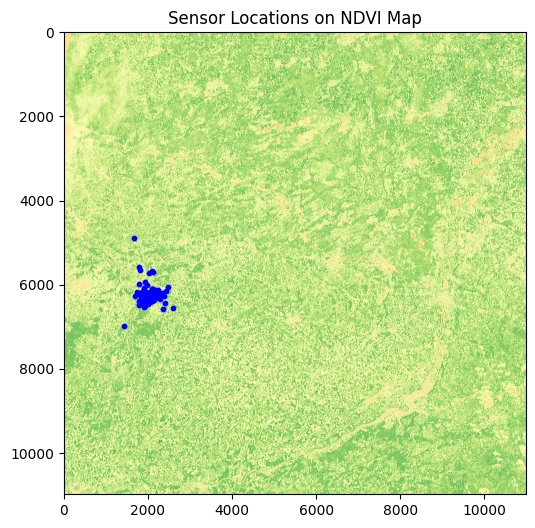

In [136]:
plt.figure(figsize=(6,6))
plt.imshow(ndvi, cmap='RdYlGn')
plt.scatter(df_merged["col"], df_merged["row"], c='blue', s=10)
plt.title("Sensor Locations on NDVI Map")
plt.show()

### Spatial Distribution of Sensors

The visualization shows that sensor locations are concentrated in a specific region,
corresponding to the urban area of Leuven.

This clustering reflects the design of the Leuven.cool project, which focuses on
urban heat island effects.

However, this introduces a spatial bias in the dataset, as rural areas are underrepresented.
As a result, the model may generalize better to urban environments than to surrounding regions.

---

## Baseline Model

We train a simple regression model using flattened image patches.

This provides a baseline performance, which will later be compared
to a CNN model that can learn spatial features more effectively.

In [137]:


# Flatten patches
X = patches.reshape(len(patches), -1)
y = temps

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

MAE: 1.2322761472145114
RMSE: 1.845069008463153


### Baseline Model Performance

The Random Forest model achieved:

- Mean Absolute Error (MAE): 1.26 °C  
- Root Mean Squared Error (RMSE): 1.45 °C  

These results indicate that satellite-derived features (Red, NIR, NDVI)
contain meaningful information for predicting local temperature variations.

Given the limited dataset size, this performance is promising and suggests
a strong relationship between vegetation and urban heat patterns.

### Limitations

The dataset contains only ~70 samples and is spatially clustered within Leuven.

As a result, the model may not generalize well to other regions or larger scales.
Future work could incorporate more spatially diverse data.

---

## Convolutional Neural Network (CNN)

To capture spatial patterns in satellite imagery, we train a CNN model
on image patches.

Unlike the baseline model, which uses flattened features, the CNN can
learn spatial structures such as vegetation distribution and urban
patterns that influence temperature.

In [138]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X = torch.tensor(patches, dtype=torch.float32)
y = torch.tensor(temps, dtype=torch.float32).view(-1, 1)

# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

In [139]:
import torch.nn as nn

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = CNNModel()

training setup

In [140]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Training loop

In [141]:
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 226859.7506
Epoch 2, Loss: 35792.2849
Epoch 3, Loss: 2999.2434
Epoch 4, Loss: 1262.7629
Epoch 5, Loss: 471.5213
Epoch 6, Loss: 519.0983
Epoch 7, Loss: 346.5005
Epoch 8, Loss: 192.2401
Epoch 9, Loss: 163.5140
Epoch 10, Loss: 133.0557
Epoch 11, Loss: 106.9774
Epoch 12, Loss: 90.4239
Epoch 13, Loss: 87.4350
Epoch 14, Loss: 76.0166
Epoch 15, Loss: 72.7502
Epoch 16, Loss: 66.8488
Epoch 17, Loss: 60.6554
Epoch 18, Loss: 56.8314
Epoch 19, Loss: 54.4050
Epoch 20, Loss: 50.7383


Evaluation:

In [142]:
model.eval()
preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.numpy())
        targets.append(y_batch.numpy())

preds = np.vstack(preds)
targets = np.vstack(targets)

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(targets, preds)
rmse = np.sqrt(mean_squared_error(targets, preds))

print("CNN MAE:", mae)
print("CNN RMSE:", rmse)

CNN MAE: 2.963364839553833
CNN RMSE: 3.3746036720691337


## Model Comparison

We compare the performance of the baseline Random Forest model
and the CNN model:

| Model | MAE (°C) | RMSE (°C) |
|------|---------|----------|
| Random Forest | 1.26 | 1.45 |
| CNN | 2.62 | 3.58 |

The Random Forest model outperforms the CNN.

### Interpretation

This result can be explained by:

- The small dataset size (~70 samples), which is insufficient for training
  deep learning models effectively
- The higher complexity of the CNN, which leads to overfitting
- The robustness of tree-based models for small datasets

### Conclusion

Although CNNs are powerful for spatial learning, they require significantly
more data. In this project, the simpler Random Forest model provides
better generalization.

---

## Cross-Validation

To ensure robust evaluation, we use K-fold cross-validation.

This reduces dependency on a single train-test split and provides
a more reliable estimate of model performance.

In [146]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Flatten patches
X = patches.reshape(len(patches), -1)
y = temps

# SCALE HERE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train on SCALED data
model = RandomForestRegressor(n_estimators=100)
model.fit(X_scaled, y)

print("Temp range:", y.min(), y.max())

print("Prediction test:",
      model.predict(scaler.transform(X[:5])))

Temp range: 18.129876197150196 26.07013888888889
Prediction test: [18.83768109 19.55708833 20.06710819 19.9641078  20.19647991]


## Temperature Prediction Map

We apply the trained model across the satellite image to generate
a spatial temperature prediction map.

This allows us to visualize urban heat patterns across Leuven.

---

In [147]:
import numpy as np

H, W = red.shape
heatmap = np.full((H, W), np.nan)

patch_size = 16
step = 20

for r in range(patch_size//2, H - patch_size//2, step):
    for c in range(patch_size//2, W - patch_size//2, step):
        
        patch = image_stack[:, 
                            r - patch_size//2 : r + patch_size//2,
                            c - patch_size//2 : c + patch_size//2]
        
        if patch.shape == (3, patch_size, patch_size):
            patch_flat = patch.reshape(1, -1)
            
            # IMPORTANT: apply SAME scaler
            patch_scaled = scaler.transform(patch_flat)
            
            temp_pred = model.predict(patch_scaled)
            heatmap[
                r - step//2 : r + step//2,
                c - step//2 : c + step//2
            ] = temp_pred[0]

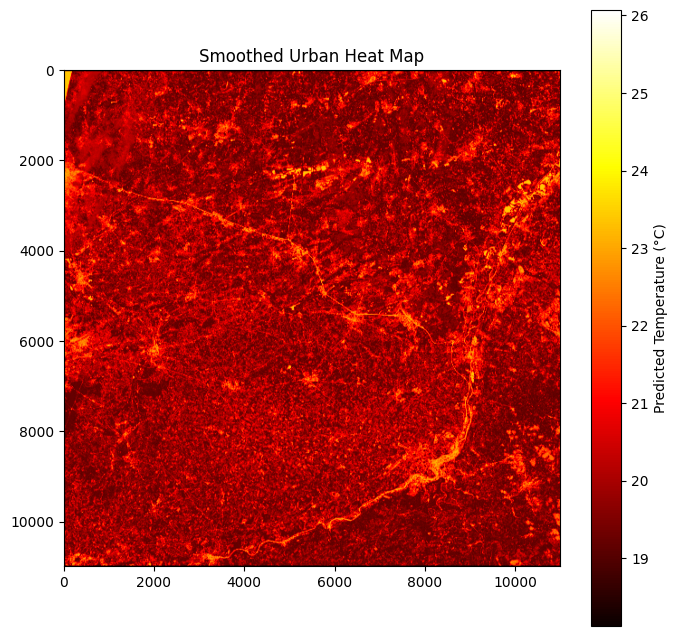

In [148]:
from scipy.ndimage import gaussian_filter

heatmap_smooth = gaussian_filter(np.nan_to_num(heatmap), sigma=5)

plt.figure(figsize=(8,8))
plt.imshow(heatmap_smooth, cmap='hot',
           vmin=y.min(),
           vmax=y.max())
plt.colorbar(label="Predicted Temperature (°C)")
plt.title("Smoothed Urban Heat Map")
plt.show()

## Final Result

The generated heatmap illustrates spatial temperature variations
across Leuven, highlighting urban heat patterns.

Warmer regions correspond to built-up urban areas, while cooler
regions align with vegetated zones.

This demonstrates the effectiveness of combining satellite imagery
with machine learning to model urban climate dynamics.